# FGTV emissions charts (smoothed with HP filter)

Two charts from `decomposed_ssp_output.csv`, both filtered with the same Hodrick-Prescott smoother used in the R post-processing pipeline (anchored to the first observed year, non-negative).

1. **FGTV emissions by component** — flaring + venting + fugitive (dtp) per strategy.
2. **FGTV emissions by gas** — CO2 + CH4 + N2O per strategy, replicating the CCD "emissions by gas" stack.

Strategy mapping:
- `6003` BAU
- `6004` Unconditional NDC (ZRF)
- `6005` Conditional NDC


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.filters.hp_filter import hpfilter

# Latest run by default (override RUN_DIR below to pin a specific run)
RUNS_ROOT = Path('/Users/fabianfuentes/git/ssp_libya/ssp_modeling/ssp_run_output')
RUN_DIR = sorted(RUNS_ROOT.glob('sisepuede_results_sisepuede_run_*'))[-1]
print('Run dir:', RUN_DIR.name)

df = pd.read_csv(RUN_DIR / 'decomposed_ssp_output.csv')
att = pd.read_csv(RUN_DIR / 'ATTRIBUTE_PRIMARY.csv')
df = df.merge(att[['primary_id','strategy_id']], on='primary_id')
df['year'] = df['time_period'] + 2015
df = df[df.strategy_id != 0].copy()   # drop BASE
print('strategies:', sorted(df.strategy_id.unique()), '| years:', df.year.min(), '->', df.year.max())

STRATEGY_NAMES = {6003: 'BAU', 6004: 'Unconditional NDC (ZRF)', 6005: 'Conditional NDC'}
STRATEGY_ORDER = [6003, 6004, 6005]
LAMBDA_HP = 1600   # matches R post-processing default for Energy CH4/CO2


Run dir: sisepuede_results_sisepuede_run_2026-04-29T23;21;32.174702
strategies: [np.int64(6003), np.int64(6004), np.int64(6005)] | years: 2023 -> 2050


## HP filter helper

Hodrick-Prescott smoother, ported from `output_postprocessing/scr/data_prep_new_mapping.r::hp_filter_subsec`:

1. Apply `hpfilter` with `freq=lambda` to the per-strategy series.
2. Floor the trend at 0 (non-negative).
3. Shift so the smoothed series passes exactly through the first observed value (anchor).
4. Floor again, then re-pin the first point.


In [2]:
def hp_smooth(series: pd.Series, lambda_hp: float = LAMBDA_HP) -> pd.Series:
    """Anchored, non-negative HP trend matching the R hp_filter_subsec output."""
    s = series.astype(float).sort_index()
    if len(s) < 2:
        return s.copy()
    _, trend = hpfilter(s.values, lamb=lambda_hp)
    sm = np.maximum(trend, 0.0)
    shift = s.values[0] - sm[0]
    sm = np.maximum(sm + shift, 0.0)
    sm[0] = s.values[0]
    return pd.Series(sm, index=s.index, name=s.name)


def smooth_by_strategy(df_long: pd.DataFrame, value_cols, lambda_hp: float = LAMBDA_HP) -> pd.DataFrame:
    """Apply hp_smooth to each value_col within each strategy_id, indexed by year."""
    out = df_long.copy()
    for col in value_cols:
        for sid, sub in out.groupby('strategy_id'):
            s = sub.set_index('year')[col]
            sm = hp_smooth(s, lambda_hp = lambda_hp)
            out.loc[sub.index, col] = out.loc[sub.index, 'year'].map(sm)
    return out


## 1 — FGTV emissions by component (flaring + venting + dtp)


In [3]:
fgtv_cols = [c for c in df.columns if c.startswith('emission_co2e_') and '_fgtv_' in c and c != 'emission_co2e_subsector_total_fgtv']
flar_cols = [c for c in fgtv_cols if '_fgtv_flaring_' in c]
vent_cols = [c for c in fgtv_cols if '_fgtv_venting_' in c]
dtp_cols  = [c for c in fgtv_cols if '_fgtv_dtp_' in c]
print(f'flaring cols: {len(flar_cols)} | venting: {len(vent_cols)} | dtp: {len(dtp_cols)}')

comp = df[['strategy_id','year']].copy()
comp['flaring'] = df[flar_cols].sum(axis=1)
comp['venting'] = df[vent_cols].sum(axis=1)
comp['dtp']     = df[dtp_cols].sum(axis=1)
comp['total']   = comp[['flaring','venting','dtp']].sum(axis=1)

comp_sm = smooth_by_strategy(comp, ['flaring','venting','dtp','total'], lambda_hp = LAMBDA_HP)
comp_sm.head()


flaring cols: 12 | venting: 12 | dtp: 12


,strategy_id,year,flaring,venting,dtp,total
0,6003,2023,6.267337,15.684255,5.076407,27.028000
1,6003,2024,7.138592,15.568561,5.037076,27.744230
2,6003,2025,8.010527,15.450191,4.996983,28.457701
3,6003,2026,8.883782,15.323396,4.954494,29.161672
4,6003,2027,9.759139,15.181228,4.907695,29.848062


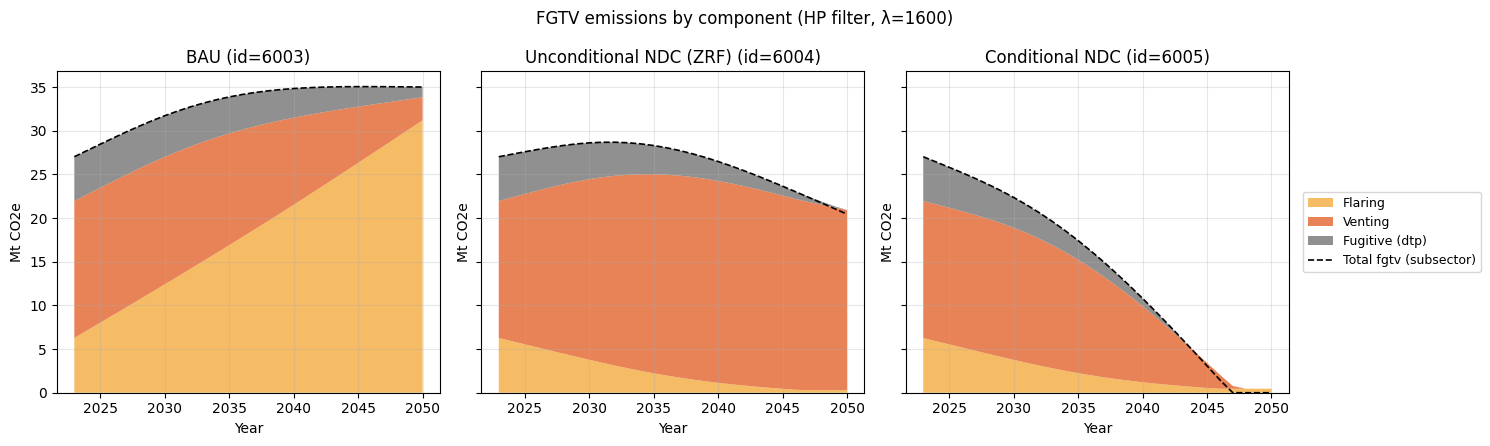

In [4]:
comp_colors = {'flaring': '#f5b04a', 'venting': '#e36d3a', 'dtp': '#7d7d7d'}
strategies_all = [s for s in STRATEGY_ORDER if s in comp_sm.strategy_id.unique()]
fig, axes = plt.subplots(1, len(strategies_all), figsize=(5.0*len(strategies_all), 4.5), sharey=True)
if len(strategies_all) == 1: axes = [axes]
for ax, sid in zip(axes, strategies_all):
    sub = comp_sm[comp_sm.strategy_id == sid].set_index('year').sort_index()
    ax.stackplot(sub.index, sub['flaring'], sub['venting'], sub['dtp'],
                 labels=['Flaring','Venting','Fugitive (dtp)'],
                 colors=[comp_colors['flaring'], comp_colors['venting'], comp_colors['dtp']], alpha=0.85)
    ax.plot(sub.index, sub['total'], 'k--', lw=1.2, label='Total fgtv (subsector)')
    ax.set_title(f"{STRATEGY_NAMES.get(sid, sid)} (id={sid})")
    ax.set_xlabel('Year'); ax.set_ylabel('Mt CO2e'); ax.grid(alpha=0.3)
axes[-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
fig.suptitle(f'FGTV emissions by component (HP filter, λ={LAMBDA_HP})')
plt.tight_layout(); plt.show()


## 2 — FGTV emissions by gas (CO2, CH4, N2O)

Same FGTV totals, but split by greenhouse gas (in CO2e). FGTV has no F-gases, so the chart is just CO2 + CH4 + N2O.


In [ ]:
co2_cols = [c for c in fgtv_cols if c.startswith('emission_co2e_co2_fgtv_')]
ch4_cols = [c for c in fgtv_cols if c.startswith('emission_co2e_ch4_fgtv_')]
n2o_cols = [c for c in fgtv_cols if c.startswith('emission_co2e_n2o_fgtv_')]
print(f'CO2 cols: {len(co2_cols)} | CH4 cols: {len(ch4_cols)} | N2O cols: {len(n2o_cols)}')

gas = df[['strategy_id','year']].copy()
gas['CO2']   = df[co2_cols].sum(axis=1)
gas['CH4']   = df[ch4_cols].sum(axis=1)
gas['N2O']   = df[n2o_cols].sum(axis=1)
gas['total'] = gas[['CO2','CH4','N2O']].sum(axis=1)

gas_sm = smooth_by_strategy(gas, ['CO2','CH4','N2O','total'], lambda_hp = LAMBDA_HP)
gas_sm.head()


In [ ]:
gas_colors = {'CO2': '#9bb7d4', 'CH4': '#f4a14a', 'N2O': '#f3c1c4'}
fig, axes = plt.subplots(1, len(strategies_all), figsize=(5.0*len(strategies_all), 4.5), sharey=True)
if len(strategies_all) == 1: axes = [axes]
anchor_year = 2035
for ax, sid in zip(axes, strategies_all):
    sub = gas_sm[gas_sm.strategy_id == sid].set_index('year').sort_index()
    ax.stackplot(sub.index, sub['CO2'], sub['CH4'], sub['N2O'],
                 labels=['CO2','CH4','N2O'],
                 colors=[gas_colors['CO2'], gas_colors['CH4'], gas_colors['N2O']], alpha=0.9)
    ax.plot(sub.index, sub['total'], 'k-', lw=1.4)
    if anchor_year in sub.index:
        ax.axvline(anchor_year, color='gray', ls='--', lw=1, alpha=0.6)
        ax.annotate(f"{sub.loc[anchor_year,'total']:.2f}", xy=(anchor_year, sub.loc[anchor_year,'total']),
                    xytext=(4, 4), textcoords='offset points', fontsize=9)
    last_year = sub.index.max()
    ax.annotate(f"{sub.loc[last_year,'total']:.2f}", xy=(last_year, sub.loc[last_year,'total']),
                xytext=(4, 4), textcoords='offset points', fontsize=9)
    ax.set_title(f"{STRATEGY_NAMES.get(sid, sid)} (id={sid})")
    ax.set_xlabel('Year'); ax.set_ylabel('Mt CO2e'); ax.grid(alpha=0.3)
axes[-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, title='Gas')
fig.suptitle(f'FGTV emissions by gas (HP filter, λ={LAMBDA_HP})')
plt.tight_layout(); plt.show()


## 3 — FGTV emissions by component AND gas

Each pathway (flaring, venting, fugitive) split by gas (CO2, CH4, N2O). Useful when you want to attribute, for example, "how much of the flaring climate impact is CO2 vs uncombusted CH4 slip."


In [ ]:
# Build a per-(pathway, gas) view from the same FGTV columns.
# Pathways use the same process tags as Section 1 (flaring / venting / dtp).
PATHWAY_TAGS = [('flaring','flaring'), ('venting','venting'), ('fugitive','dtp')]
GAS_TAGS     = [('CO2','co2'), ('CH4','ch4'), ('N2O','n2o')]
FGTV_FUELS   = ['coal','crude','natural_gas','oil']

# Wide -> long: one row per (strategy_id, year, pathway, gas)
wide = df[['strategy_id','year']].copy()
for path_label, path_tag in PATHWAY_TAGS:
    for gas_label, gas_tag in GAS_TAGS:
        cols = [f'emission_co2e_{gas_tag}_fgtv_{path_tag}_fuel_{f}' for f in FGTV_FUELS]
        cols = [c for c in cols if c in df.columns]
        wide[f'{path_label}__{gas_label}'] = df[cols].sum(axis=1) if cols else 0.0

value_cols = [f'{p}__{g}' for p, _ in PATHWAY_TAGS for g, _ in GAS_TAGS]
pxg = wide.melt(
    id_vars   = ['strategy_id','year'],
    value_vars = value_cols,
    var_name  = 'pathway_gas',
    value_name = 'value',
)
pxg[['pathway','gas']] = pxg['pathway_gas'].str.split('__', expand=True)
pxg = pxg.drop(columns=['pathway_gas'])

# HP-smooth per (strategy, pathway, gas) series, anchored at the first year.
pxg_sm = pxg.copy()
for (sid, path, gas), sub in pxg.groupby(['strategy_id','pathway','gas']):
    s = sub.set_index('year')['value']
    sm = hp_smooth(s, LAMBDA_HP)
    pxg_sm.loc[sub.index, 'value'] = pxg_sm.loc[sub.index, 'year'].map(sm)

pxg_sm.head(12)


In [ ]:
# Small multiples: rows = pathway, cols = strategy. Each cell stacks CO2/CH4/N2O.
gas_color = {'CO2': '#9bb7d4', 'CH4': '#f4a14a', 'N2O': '#f3c1c4'}
pathways  = ['flaring', 'venting', 'fugitive']

fig, axes = plt.subplots(
    len(pathways), len(strategies_all),
    figsize=(5.0*len(strategies_all), 3.4*len(pathways)),
    sharex=True, sharey='row',
)
if len(pathways) == 1: axes = axes[None, :]
if len(strategies_all) == 1: axes = axes[:, None]

for r, path in enumerate(pathways):
    for c, sid in enumerate(strategies_all):
        ax = axes[r, c]
        sub = (pxg_sm[(pxg_sm.strategy_id == sid) & (pxg_sm.pathway == path)]
               .pivot(index='year', columns='gas', values='value')
               .sort_index())
        gases_present = [g for g in ['CO2','CH4','N2O'] if g in sub.columns]
        ax.stackplot(sub.index,
                     [sub[g].fillna(0) for g in gases_present],
                     labels=gases_present,
                     colors=[gas_color[g] for g in gases_present], alpha=0.9)
        total = sub[gases_present].sum(axis=1)
        ax.plot(sub.index, total, 'k-', lw=1.2)
        if r == 0:
            ax.set_title(f"{STRATEGY_NAMES.get(sid, sid)}", fontsize=11)
        if c == 0:
            ax.set_ylabel(f"{path}\nMt CO2e", fontsize=10)
        if r == len(pathways) - 1:
            ax.set_xlabel('Year')
        ax.grid(alpha=0.3)
        last_year = sub.index.max()
        ax.annotate(f"{total.loc[last_year]:.2f}",
                    xy=(last_year, total.loc[last_year]),
                    xytext=(4, 4), textcoords='offset points', fontsize=8)

axes[0, -1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, title='Gas')
fig.suptitle(f'FGTV emissions by component × gas (HP filter, λ={LAMBDA_HP})', y=1.0)
plt.tight_layout(); plt.show()


## Export for Tableau

Long-format CSV with the same schema used by the existing Tableau workbook: `year, strategy_id, strategy_name, chart, metric, facility_type, value, units`. Smoothed values are exported (HP filter applied).

- `chart='fgtv_components'`: metrics `flar_emis_mt_co2e`, `vent_ch4_mt_co2e`, `dtp_ch4_mt_co2e`, `total_fgtv_mt_co2e`.
- `chart='fgtv_by_gas'`: metrics `fgtv_co2_mt_co2e`, `fgtv_ch4_mt_co2e`, `fgtv_n2o_mt_co2e`, `total_fgtv_mt_co2e`.
- `chart='fgtv_components_by_gas'`: metrics `<pathway>_<gas>_mt_co2e` for every pathway × gas combination (9 rows per year per strategy).

Saved to `ssp_modeling/tableau/data/oilgas_ccd_charts_libya.csv` (overwriting prior file).


In [ ]:
rows = []

# Chart A: FGTV components (smoothed)
comp_metric_map = {
    'flaring': ('flar_emis_mt_co2e', 'Mt CO2e'),
    'venting': ('vent_ch4_mt_co2e',  'Mt CO2e'),
    'dtp':     ('dtp_ch4_mt_co2e',   'Mt CO2e'),
    'total':   ('total_fgtv_mt_co2e','Mt CO2e'),
}
for _, r in comp_sm.iterrows():
    sid = int(r['strategy_id'])
    for col, (metric, units) in comp_metric_map.items():
        rows.append({
            'year': int(r['year']), 'strategy_id': sid,
            'strategy_name': STRATEGY_NAMES.get(sid, str(sid)),
            'chart': 'fgtv_components', 'metric': metric,
            'facility_type': 'All', 'value': float(r[col]), 'units': units,
        })

# Chart B: FGTV by gas (smoothed)
gas_metric_map = {
    'CO2':   ('fgtv_co2_mt_co2e',  'Mt CO2e'),
    'CH4':   ('fgtv_ch4_mt_co2e',  'Mt CO2e'),
    'N2O':   ('fgtv_n2o_mt_co2e',  'Mt CO2e'),
    'total': ('total_fgtv_mt_co2e','Mt CO2e'),
}
for _, r in gas_sm.iterrows():
    sid = int(r['strategy_id'])
    for col, (metric, units) in gas_metric_map.items():
        rows.append({
            'year': int(r['year']), 'strategy_id': sid,
            'strategy_name': STRATEGY_NAMES.get(sid, str(sid)),
            'chart': 'fgtv_by_gas', 'metric': metric,
            'facility_type': 'All', 'value': float(r[col]), 'units': units,
        })

# Chart C: FGTV components × gas (smoothed)
for _, r in pxg_sm.iterrows():
    sid = int(r['strategy_id'])
    metric = f"{r['pathway']}_{r['gas'].lower()}_mt_co2e"
    rows.append({
        'year': int(r['year']), 'strategy_id': sid,
        'strategy_name': STRATEGY_NAMES.get(sid, str(sid)),
        'chart': 'fgtv_components_by_gas', 'metric': metric,
        'facility_type': 'All', 'value': float(r['value']), 'units': 'Mt CO2e',
    })

tab = pd.DataFrame(rows, columns=['year','strategy_id','strategy_name','chart','metric','facility_type','value','units'])
out_path = Path('/Users/fabianfuentes/git/ssp_libya/ssp_modeling/tableau/data/oilgas_ccd_charts_libya.csv')
out_path.parent.mkdir(parents=True, exist_ok=True)
tab.to_csv(out_path, index=False)
print(f'Wrote {len(tab)} rows to {out_path}')
print('chart values :', sorted(tab.chart.unique()))
print('metric values:', sorted(tab.metric.unique()))
tab.head()


## Notes

- `LAMBDA_HP=1600` matches the R post-processing default used for Energy CH4/CO2 series. Use 600 for noisier series, 100 for almost-no-smoothing.
- The first observed year (2023) is anchored exactly to the model output. Smoothing only affects later years.
- The dashed black line on chart 1 is the FGTV subsector total (sanity check: should equal the stacked sum).
